#  IMPORTS


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
 

# Loading Data

In [22]:
train_df = pd.read_csv('ct_slice_train.csv')
test_df  = pd.read_csv('ct_slice_test_noLabels.csv')
 
print(f"Train shape : {train_df.shape}")   
print(f"Test shape  : {test_df.shape}")   
print(f"Train columns (last 3): {train_df.columns[-3:].tolist()}")
print(f"Test columns  (last 3): {test_df.columns[-3:].tolist()}")

Train shape : (42800, 386)
Test shape  : (10700, 385)
Train columns (last 3): ['value382', 'value383', 'TARGET']
Test columns  (last 3): ['value381', 'value382', 'value383']


# Separating Features and Target

In [23]:
# Drop ID column, separate features and target
feature_cols = [f'value{i}' for i in range(384)]
 
X_train_raw = train_df[feature_cols].values          
y_train_raw = train_df['TARGET'].values              
X_test_raw  = test_df[feature_cols].values           
test_ids    = test_df['ID'].values                   
 


In [24]:
print(f"\nX_train_raw shape : {X_train_raw.shape}")
print(f"y_train_raw shape : {y_train_raw.shape}")
print(f"X_test_raw shape  : {X_test_raw.shape}")
print(f"\nTARGET range: {y_train_raw.min():.2f} to {y_train_raw.max():.2f}")
 


X_train_raw shape : (42800, 384)
y_train_raw shape : (42800,)
X_test_raw shape  : (10700, 384)

TARGET range: 1.74 to 97.32


# NORMALIZE FEATURES (Z-SCORE)


In [25]:
train_mean = X_train_raw.mean(axis=0)   # shape (384,)
train_std  = X_train_raw.std(axis=0)    # shape (384,)
 
# Avoid division by zero for constant features
train_std[train_std == 0] = 1.0
 
X_train_norm = (X_train_raw - train_mean) / train_std
X_test_norm  = (X_test_raw  - train_mean) / train_std   # use TRAIN stats
 


In [26]:
print(f"\nAfter normalization:")
print(f"X_train mean (first 3 features): {X_train_norm[:, :3].mean(axis=0).round(4)}")
print(f"X_train std  (first 3 features): {X_train_norm[:, :3].std(axis=0).round(4)}")
 


After normalization:
X_train mean (first 3 features): [-0.  0. -0.]
X_train std  (first 3 features): [1. 1. 1.]


# Converting to Tensors

In [27]:
X = torch.tensor(X_train_norm, dtype=torch.float32)
y = torch.tensor(y_train_raw,  dtype=torch.float32).unsqueeze(1)  # shape (42800, 1)
X_test = torch.tensor(X_test_norm, dtype=torch.float32)
 
print(f"\nX tensor shape : {X.shape}")
print(f"y tensor shape : {y.shape}")
print(f"X_test tensor  : {X_test.shape}")


X tensor shape : torch.Size([42800, 384])
y tensor shape : torch.Size([42800, 1])
X_test tensor  : torch.Size([10700, 384])


# Train / Validation Split 

In [28]:
torch.manual_seed(0)
full_dataset = TensorDataset(X, y)
train_size   = int(0.8 * len(full_dataset))
val_size     = len(full_dataset) - train_size
 
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
 
print(f"\nTrain samples      : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")


Train samples      : 34240
Validation samples : 8560


# Dataloaders

In [29]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
 
print(f"\nBatches per epoch (train) : {len(train_loader)}")
print(f"Batches per epoch (val)   : {len(val_loader)}")


Batches per epoch (train) : 535
Batches per epoch (val)   : 134


# MODEL

In [30]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_sizes, out_features):
        super().__init__()
        sizes  = [in_features] + hidden_sizes
        layers = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i+1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(sizes[-1], out_features))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


torch.manual_seed(0)
model = MLP(in_features=384, hidden_sizes=[256, 128, 64], out_features=1)
print(f"\nModel architecture:\n{model}")





Model architecture:
MLP(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [31]:
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")


Total parameters: 139,777


# Loss Function and Optimizer

In [32]:
loss_fn   = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
 
print(f"\nLoss     : MSELoss (regression)")
print(f"Optimizer: Adam  (lr=0.001)")
print(f"Scheduler: StepLR (step=10, gamma=0.5)")


Loss     : MSELoss (regression)
Optimizer: Adam  (lr=0.001)
Scheduler: StepLR (step=10, gamma=0.5)


# Training Loop 

In [33]:
def train_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total = 0.0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(X_batch)
    return total / len(loader.dataset)
 
def val_epoch(model, loader, loss_fn):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            loss = loss_fn(model(X_batch), y_batch)
            total += loss.item() * len(X_batch)
    return total / len(loader.dataset)
 
 
N_EPOCHS     = 30
train_losses = []
val_losses   = []
 
print(f"\nTraining for {N_EPOCHS} epochs...\n")
 



Training for 30 epochs...



In [ ]:
for epoch in range(N_EPOCHS):
    t_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    v_loss = val_epoch(model, val_loader, loss_fn)
    scheduler.step()
 
    train_losses.append(t_loss)
    val_losses.append(v_loss)
 
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS}  |  train MSE: {t_loss:.4f}  |  val MSE: {v_loss:.4f}")
 
print(f"\nFinal train MSE : {train_losses[-1]:.4f}")
print(f"Final val   MSE : {val_losses[-1]:.4f}")
print(f"Final val  RMSE : {val_losses[-1]**0.5:.4f}  (in same units as TARGET)")
 

Epoch   5/30  |  train MSE: 3.3811  |  val MSE: 4.0275
Epoch  10/30  |  train MSE: 1.5024  |  val MSE: 2.6199
Epoch  15/30  |  train MSE: 0.7205  |  val MSE: 1.5619
Epoch  20/30  |  train MSE: 0.5492  |  val MSE: 1.3829
Epoch  25/30  |  train MSE: 0.2739  |  val MSE: 0.8543
Epoch  30/30  |  train MSE: 0.2326  |  val MSE: 0.8005

Final train MSE : 0.2326
Final val   MSE : 0.8005
Final val  RMSE : 0.8947  (in same units as TARGET)


# Train vs Validation Loss

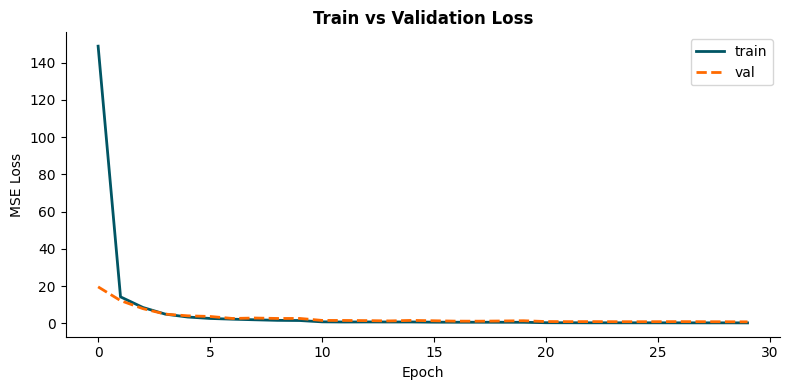

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, color='#005564', linewidth=2, label='train')
ax.plot(val_losses,   color='#FF6A00', linewidth=2, label='val', linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Train vs Validation Loss', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Save the Model

In [36]:
torch.save(model.state_dict(), 'ct_model.pt')
print("\nModel saved to ct_model.pt")


Model saved to ct_model.pt


# Predicting on test dataset

In [37]:
model.eval()
with torch.no_grad():
    predictions = model(X_test).squeeze().numpy()   # shape (10700,)
 
print(f"\nPredictions shape : {predictions.shape}")
print(f"Predictions range : {predictions.min():.2f} to {predictions.max():.2f}")
print(f"Sample predictions: {predictions[:5].round(2)}")


Predictions shape : (10700,)
Predictions range : 3.34 to 96.55
Sample predictions: [50.76 39.93 72.61 53.84 80.07]


In [38]:
submission = pd.DataFrame({
    'ID'    : test_ids,
    'TARGET': predictions
})
 
submission.to_csv('submission_cl.csv', index=False)
print(f"\nsubmission_cl.csv saved!")
print(submission.head(10))


submission_cl.csv saved!
      ID     TARGET
0  42800  50.755287
1  42801  39.934525
2  42802  72.608551
3  42803  53.842365
4  42804  80.068802
5  42805  80.822807
6  42806  70.490952
7  42807  35.282234
8  42808  65.387451
9  42809  55.272903
